In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
bank = pd.read_csv('../data/bank_churn_data.csv')
bank.head()

,user_id,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,...,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
bank.shape

(10127, 21)

In [ ]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10127 non-null  int64  
 1   attrition_flag            10127 non-null  object 
 2   customer_age              10127 non-null  int64  
 3   gender                    10127 non-null  object 
 4   dependent_count           10127 non-null  int64  
 5   education_level           10127 non-null  object 
 6   marital_status            10127 non-null  object 
 7   income_category           10127 non-null  object 
 8   card_category             10127 non-null  object 
 9   months_on_book            10127 non-null  int64  
 10  total_relationship_count  10127 non-null  int64  
 11  months_inactive_12_mon    10127 non-null  int64  
 12  contacts_count_12_mon     10127 non-null  int64  
 13  credit_limit              10127 non-null  float64
 14  total_

# BUSINESS UNDERSTANDING

In [ ]:
#calculate total customer by status
total_cust = len(bank)
churn_status = bank['attrition_flag'].value_counts()

#persentase
churn_percentage = (churn_status['Attrited Customer'] / total_cust) * 100

print(f'total customer:', total_cust)
print(f'churn status:', churn_status['Attrited Customer'])
print(f'churn percentage:', churn_percentage)

total customer: 10127
churn status: 1627
churn percentage: 16.065962279055988


In [ ]:
#estimated impact on revenu
#calculate total transaction from customer who will churn
loss_rev = bank[bank['attrition_flag'] == 'Attrited Customer']['total_trans_amt'].sum()

#calculate average of transaction per customer churn
avg_trans = bank[bank['attrition_flag'] == 'Attrited Customer']['total_trans_amt'].mean()

print(f'total potential revenue that will be lost (year):', loss_rev)
print(f'average loss per customer churn:', avg_trans)

total potential revenue that will be lost (year): 5035607
average loss per customer churn: 3095.025814382299


note: total churn rate is 16.07% with potential loss of revenue (year) 5.035.607, and average loss per customer is 3.095, which is big enough. so that's why the model is needed to predict who will churn. so that strategies can be implemented to avoid losses due to churn.

note: metrik utama yang digunakan adalah 'Recall' untuk melihat kemampuan model menangkap sebanyak mungkin potensial churn.

resiko bisnis:

- FN (False Negative), saat model mengatakan customer akan bertahan tetapi aslinya churn. Bank akan mengalami kerugian utamanya dari revenue.

- FP (False Positive), saat model menebak customer akan churn tetapi aslinya bertahan. Bank akan mengalami pemborosan anggaran (misal pemasaran atau diskon) untuk approach ke customer terindikasi churn, tetapi sebenarnya mereka tidak churn.

# EDA

In [ ]:
bank_new = bank.copy()

In [ ]:
#drop column user_id
bank.drop('user_id', axis=1, inplace=True)

In [ ]:
target_col = 'attrition_flag'


cat_col = bank.select_dtypes(include='object').columns.tolist()
if target_col in cat_col:
  cat_col.remove(target_col)


num_col = bank.select_dtypes(exclude='object').columns.tolist()


print('Categorical Columns:', cat_col)
print('Numerical Columns:', num_col)

Categorical Columns: ['gender', 'education_level', 'marital_status', 'income_category', 'card_category']
Numerical Columns: ['customer_age', 'dependent_count', 'months_on_book', 'total_relationship_count', 'months_inactive_12_mon', 'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal', 'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt', 'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio']


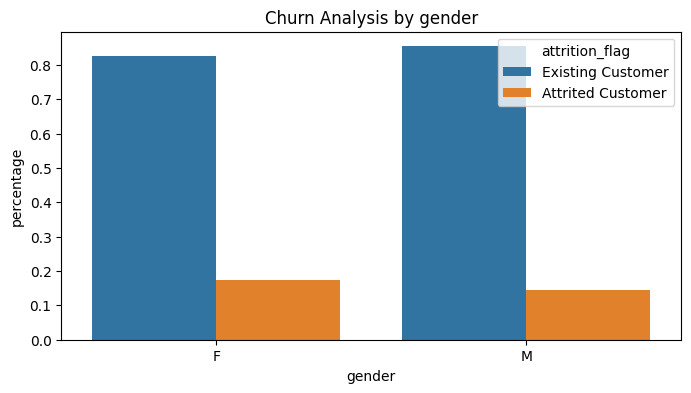

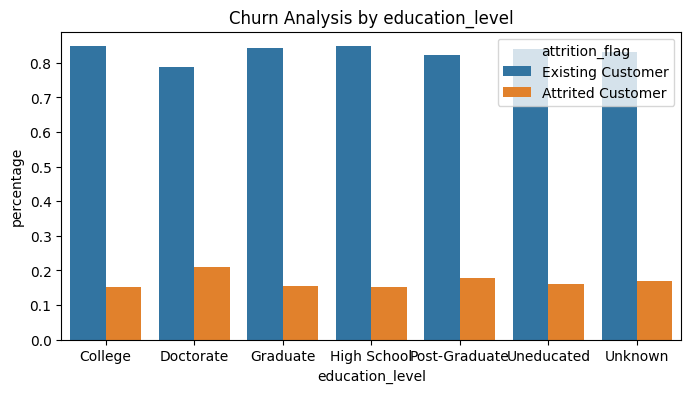

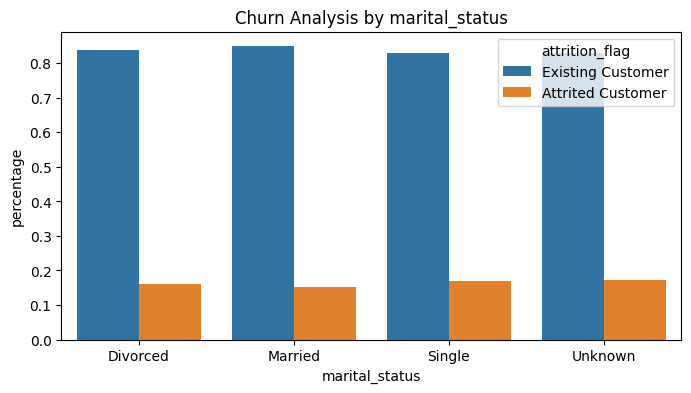

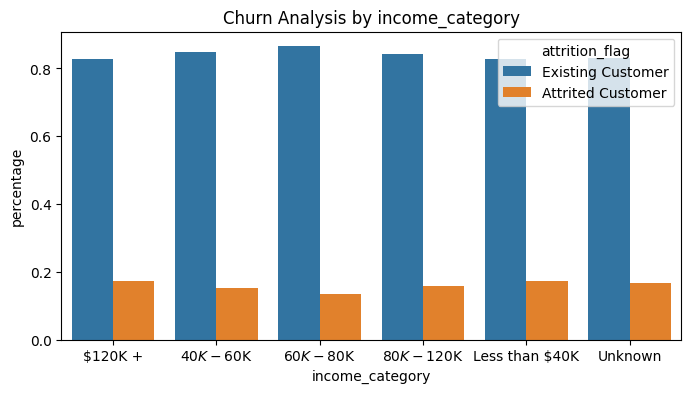

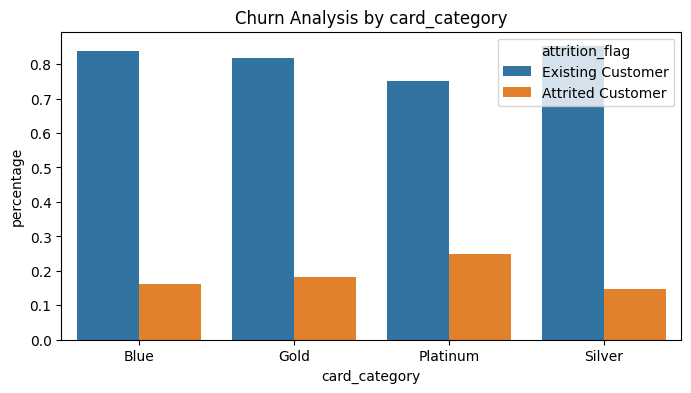

In [ ]:
#churn analysis by catgorical feature
for col in cat_col:
  plt.figure(figsize=(8, 4))
  comp_vis = bank.groupby(col)[target_col].value_counts(normalize=True).rename('percentage').reset_index()
  sns.barplot(x=col, y='percentage', hue=target_col, data=comp_vis)
  plt.title(f'Churn Analysis by {col}')
  plt.show()

note:

**Gender**: female memiliki proporsi churn lebih tinggi dibandingkan male

**Education level**: background pendidikan doctorate memiliki proporsi churn tertinggi diantara semua latar belakang pendidikan yang ada

**Marital status**: tidak ada perbedaan signifikan churn antara single, divorced, dan married

**Income category**: kategori pendapatan less than 40k dan kategori pendapatan tertinggi 120k memiliki proporsi churn sedikit lebih tinggi. hal ini memberikan informasi bahwa churn tidak hanya dari ekonomi bawah tapi juga dari kategori ekonomi atas

**Card category**: kategori pengguna kartu platinum memiliki tingkat churn yang paling tinggi, meskipun jumlah nasabahnya mungkin sedikit. namun ini menjadi insight bagi pihak bank khususnya manajemen kartu premium

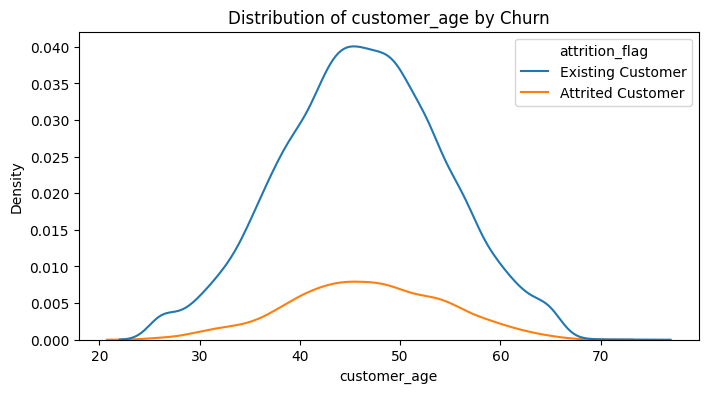

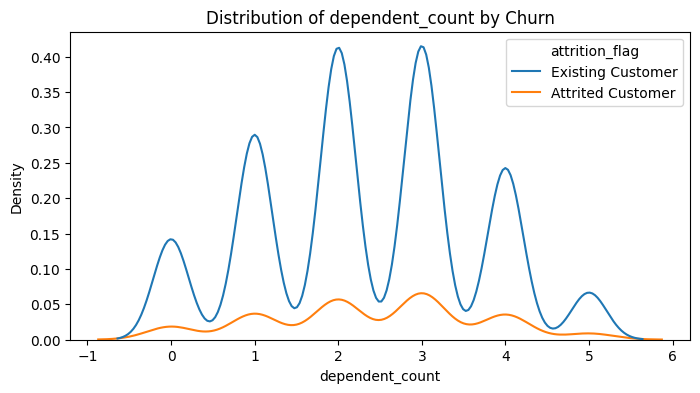

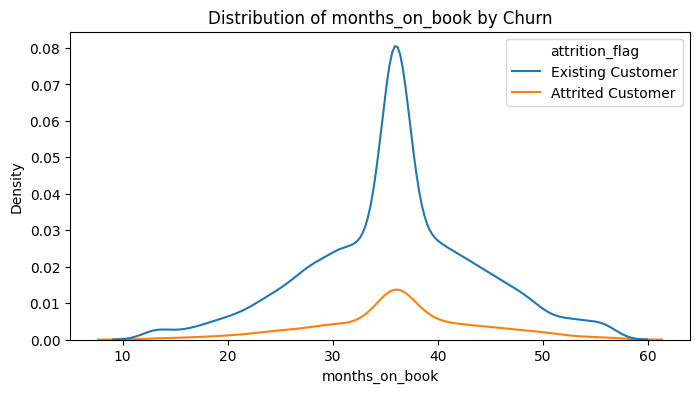

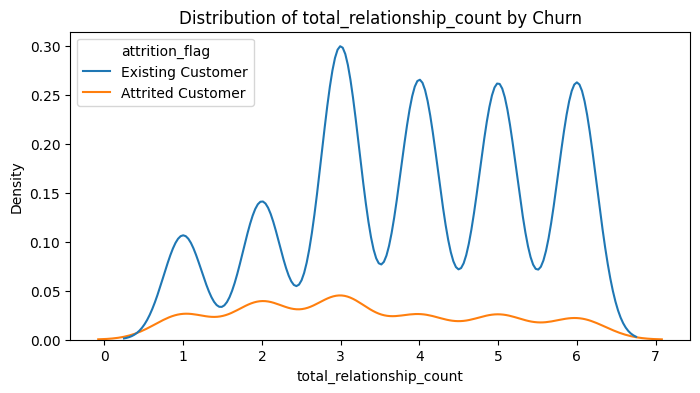

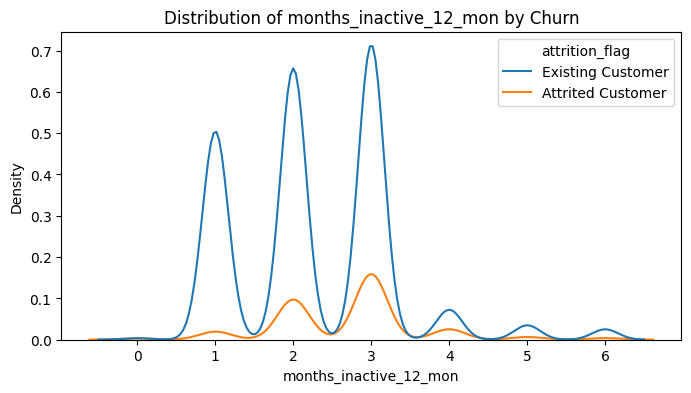

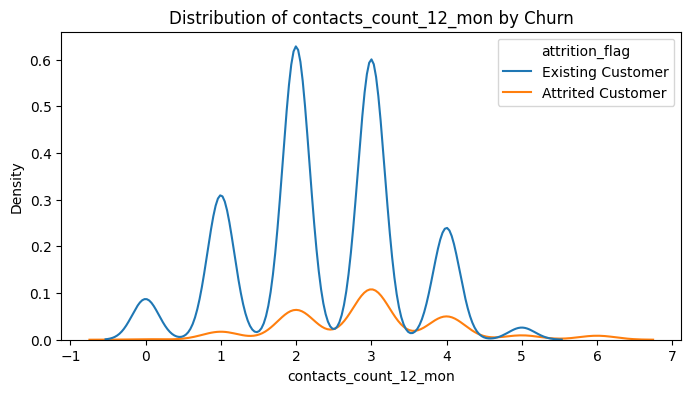

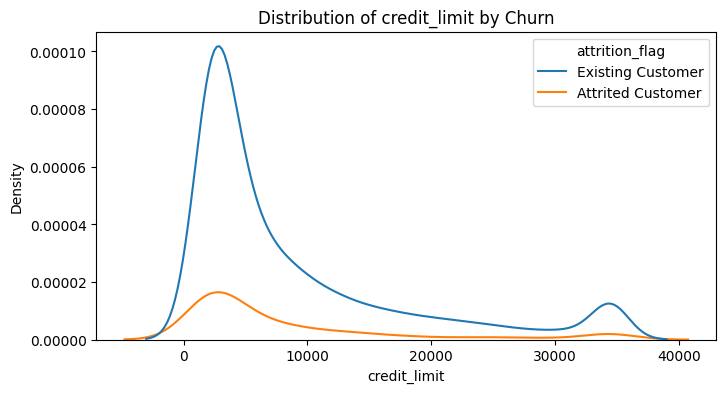

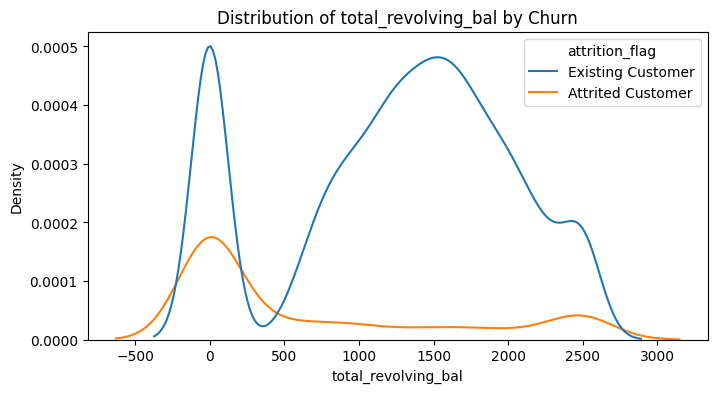

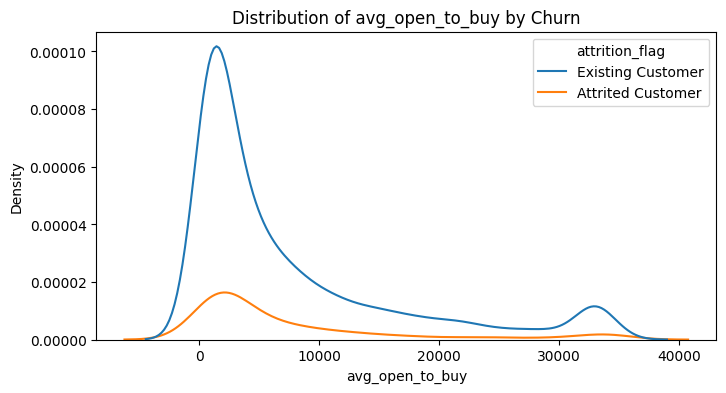

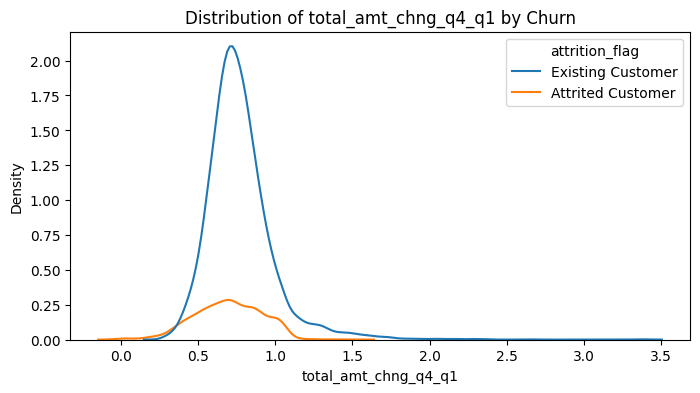

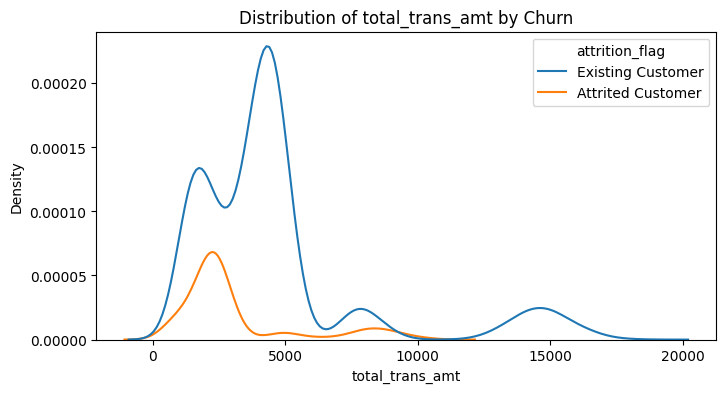

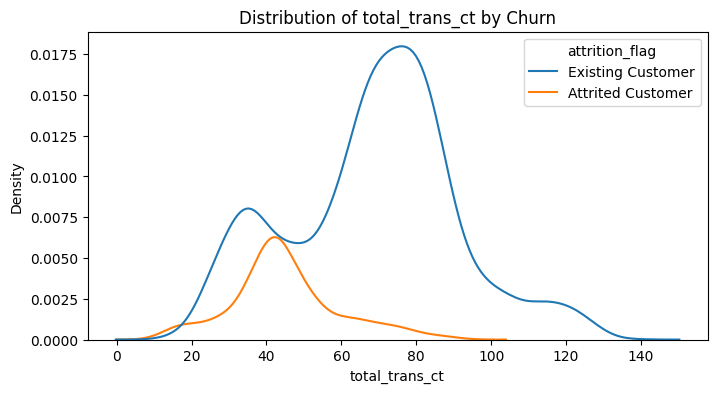

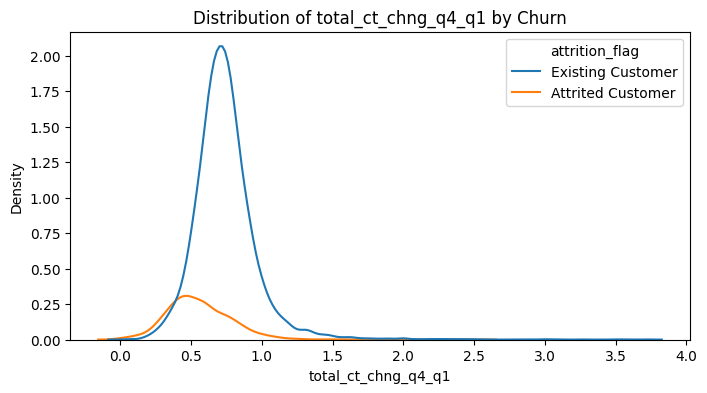

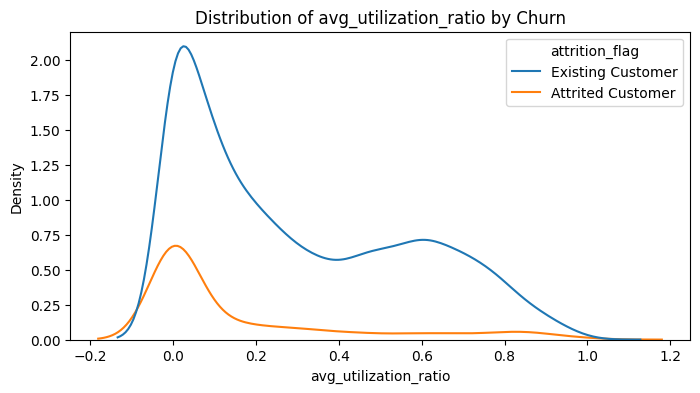

In [ ]:
#churn analysis by numerical feature
for col in num_col:
  plt.figure(figsize=(8, 4))
  sns.kdeplot(x=col, hue=target_col, data=bank)
  plt.title(f'Distribution of {col} by Churn')
  plt.show()

note:

**Revolving balance**: ini menjadi fitur/prediktor terkuat (mengindikasikan keterikatan), dimana nasabah dengan total revolving mendekati 0 paling banyak melakukan churn. hal ini masuk akal secara bisnis, karena jika tidak ada saldo maka nasabah tidak ada keterikatan untuk tidak meninggalkan bank

**Total transaction amount & count**: untuk total transaksi (amount) sekitar 2.500 dan total transaksi (count) sekitar 40 kali, memiliki tingkat churn yang tinggi

**Months inactive**: tingkat churn tinggi pada nasabah yang tidak aktif selama 3 bulan

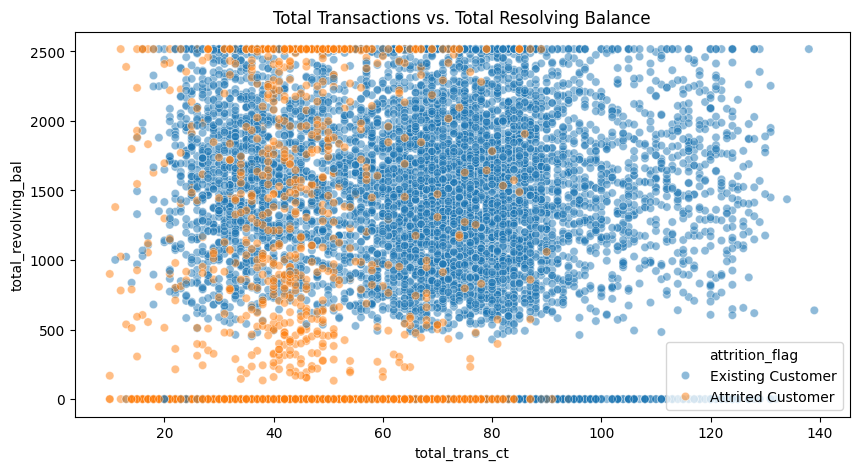

In [ ]:
#segmen with highest risk
plt.figure(figsize=(10, 5))
sns.scatterplot(data=bank, x='total_trans_ct', y='total_revolving_bal', hue='attrition_flag', alpha=0.5)
plt.title('Total Transactions vs. Total Resolving Balance')
plt.show()

# DATA PREPROCESSING

## Split

In [ ]:
#check missing value
bank.isnull().sum()

,0
attrition_flag,0
customer_age,0
gender,0
dependent_count,0
education_level,0
marital_status,0
income_category,0
card_category,0
months_on_book,0
total_relationship_count,0


In [ ]:
#check duplicate data
bank.duplicated().sum()

np.int64(0)

In [ ]:
#check 'unknown' because there are unknown value
#columns with object type
col_cate = bank.select_dtypes(include='object').columns

#total of unknown
total_unknown = []
for col in col_cate:
  count = bank[bank[col]== 'Unknown'].shape[0]
  in_percentage = (count / len(bank)) * 100
  total_unknown.append({'column': col, 'unknown_count': count, 'percentage': f"{in_percentage:.2f}%"})

unknown_bank = pd.DataFrame(total_unknown)
print(unknown_bank[unknown_bank['unknown_count'] > 0])

            column  unknown_count percentage
2  education_level           1519     15.00%
3   marital_status            749      7.40%
4  income_category           1112     10.98%


note: because there is a considerable amount of 'unknown' data, it is not recommended to drop it, and it will be handled during encoding by making it a separate feature

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [ ]:
x = bank.drop('attrition_flag', axis=1)
y = bank['attrition_flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

In [ ]:
#split 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((8101, 19), (2026, 19), (8101,), (2026,))

*note: drop user_id, because it's not an internal feature modeling*

## Encoding

In [ ]:
#encoding for categorical features
#one-hot encoding
x_train_encoded = pd.get_dummies(x_train, columns=cat_col)
x_test_encoded = pd.get_dummies(x_test, columns=cat_col)

#synchronization between train and test
x_test_encoded = x_test_encoded.reindex(columns=x_train_encoded.columns, fill_value=0)

print(x_train_encoded.shape[1])

37


In [ ]:
#checking
check_col = [col for col in x_train_encoded.columns if len(x_test_encoded[col].unique()) <= 1]
print(f'constant columns:', check_col)

constant columns: []


In [ ]:
x_train_encoded

,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,...,income_category_$120K +,income_category_$40K - $60K,income_category_$60K - $80K,income_category_$80K - $120K,income_category_Less than $40K,income_category_Unknown,card_category_Blue,card_category_Gold,card_category_Platinum,card_category_Silver
9066,54,1,36,1,3,3,3723.0,1728,1995.0,0.595,...,False,False,False,False,False,True,True,False,False,False
5814,58,4,48,1,4,3,5396.0,1803,3593.0,0.493,...,False,False,False,False,False,True,True,False,False,False
792,45,4,36,6,1,3,15987.0,1648,14339.0,0.732,...,False,False,False,False,True,False,False,True,False,False
1791,34,2,36,4,3,4,3625.0,2517,1108.0,1.158,...,False,False,False,False,True,False,True,False,False,False
5011,49,2,39,5,3,4,2720.0,1926,794.0,0.602,...,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,44,1,38,3,2,5,4142.0,2517,1625.0,0.809,...,False,True,False,False,False,False,True,False,False,False
5191,53,3,36,4,3,6,7939.0,0,7939.0,0.551,...,False,False,False,False,False,True,True,False,False,False
5390,42,4,32,3,1,2,2314.0,1547,767.0,0.804,...,False,False,False,False,True,False,True,False,False,False
860,40,3,28,4,1,1,3563.0,1707,1856.0,0.506,...,False,True,False,False,False,False,True,False,False,False


In [ ]:
#change true false to 0 1
x_train_encoded = x_train_encoded.astype(int)
x_test_encoded = x_test_encoded.astype(int)

In [ ]:
x_train_encoded

,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,...,income_category_$120K +,income_category_$40K - $60K,income_category_$60K - $80K,income_category_$80K - $120K,income_category_Less than $40K,income_category_Unknown,card_category_Blue,card_category_Gold,card_category_Platinum,card_category_Silver
9066,54,1,36,1,3,3,3723,1728,1995,0,...,0,0,0,0,0,1,1,0,0,0
5814,58,4,48,1,4,3,5396,1803,3593,0,...,0,0,0,0,0,1,1,0,0,0
792,45,4,36,6,1,3,15987,1648,14339,0,...,0,0,0,0,1,0,0,1,0,0
1791,34,2,36,4,3,4,3625,2517,1108,1,...,0,0,0,0,1,0,1,0,0,0
5011,49,2,39,5,3,4,2720,1926,794,0,...,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,44,1,38,3,2,5,4142,2517,1625,0,...,0,1,0,0,0,0,1,0,0,0
5191,53,3,36,4,3,6,7939,0,7939,0,...,0,0,0,0,0,1,1,0,0,0
5390,42,4,32,3,1,2,2314,1547,767,0,...,0,0,0,0,1,0,1,0,0,0
860,40,3,28,4,1,1,3563,1707,1856,0,...,0,1,0,0,0,0,1,0,0,0


## Scaling

In [ ]:
scaler = StandardScaler()

#scaling in numerical feature
#columns resulting from one-hot encoding are deliberately not scaled to maintain the integrity of 0 and 1
#and to prevent unnecessary bias on categorical feature that have low frequency
x_train_encoded[num_col] = scaler.fit_transform(x_train_encoded[num_col])
x_test_encoded[num_col] = scaler.transform(x_test_encoded[num_col])

## Correlation analysis

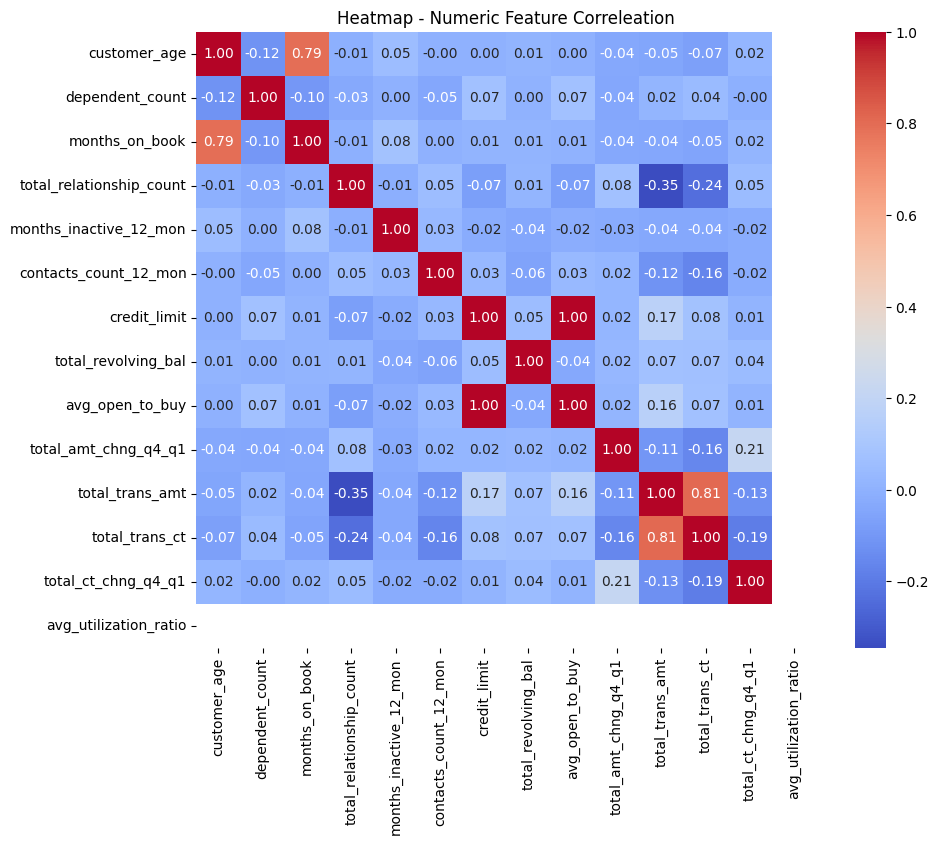

In [ ]:
#correlation analysis (numeric)
plt.figure(figsize=(10, 8))
sns.heatmap(x_train_encoded[num_col].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap - Numeric Feature Correleation')
plt.show()

note: there are multicollinearity

- credit_limit & avg_open_to_buy
- total_trans_amt & total_trans_ct
- customer_age & months_on_book

I will drop 'avg_open_to_buy' because we already have 'credit_limit' and 'total_revolving_bal' which can represent 'avg_open_to_buy'

Although a high correlation was found in the pairs 'total_trans_amt' & 'total_trans_ct' (0.81) as well as 'customer_age' & 'months_on_book' (0.79), these features are still retained. This is because each feature carries unique information (frequency vs transaction volume, and age vs time loyalty) that is crucial for the classification model.


---Random Forest or XGBoost algorithm can handle this---


In [ ]:
#delete feature
x_train_encoded.drop(columns=['avg_open_to_buy'], inplace=True)
x_test_encoded.drop(columns=['avg_open_to_buy'], inplace=True)

## Smote

In [ ]:
#check distribution data target (imbalance)
y_train.value_counts()

,count
attrition_flag,
0,6801
1,1300


In [ ]:
y_train.head(2)

,attrition_flag
9066,0
5814,1


In [ ]:
smote = SMOTE(random_state=42)

#resampling for train data
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_encoded, y_train)

#check
print(y_train_resampled.value_counts(normalize=True) * 100)

attrition_flag
0    50.0
1    50.0
Name: proportion, dtype: float64


In [ ]:
y_train_resampled.value_counts()

,count
attrition_flag,
0,6801
1,6801


In [ ]:
x_train_resampled

,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_amt_chng_q4_q1,total_trans_amt,...,income_category_$120K +,income_category_$40K - $60K,income_category_$60K - $80K,income_category_$80K - $120K,income_category_Less than $40K,income_category_Unknown,card_category_Blue,card_category_Gold,card_category_Platinum,card_category_Silver
0,0.959061,-1.035122,0.009523,-1.812952,0.644039,0.499433,-0.540788,0.696075,-0.329423,1.220348,...,0,0,0,0,0,1,1,0,0,0
1,1.457688,1.291390,1.505062,-1.812952,1.630121,0.499433,-0.356656,0.788048,-0.329423,-0.674993,...,0,0,0,0,0,1,1,0,0,0
2,-0.162849,1.291390,0.009523,1.409234,-1.328125,0.499433,0.809000,0.597970,-0.329423,-0.872259,...,0,0,0,0,1,0,0,1,0,0
3,-1.534073,-0.259618,0.009523,0.120360,0.644039,1.408012,-0.551574,1.663634,2.917120,-0.525353,...,0,0,0,0,1,0,1,0,0,0
4,0.335778,-0.259618,0.383408,0.764797,0.644039,1.408012,-0.651179,0.938885,-0.329423,-0.175507,...,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13597,-0.491138,0.024571,-0.136007,-0.760236,0.644039,0.166477,-0.119103,-1.039968,-0.329423,-0.716765,...,0,0,1,0,0,0,1,0,0,0
13598,-0.035305,-0.070233,-0.586070,0.277737,0.644039,-0.409147,-0.629995,-1.187302,-0.329423,-0.394256,...,0,1,0,0,0,0,1,0,0,0
13599,2.072092,-1.810626,1.901141,-0.455220,0.608918,0.499433,0.321585,-1.385865,-0.329423,-0.589382,...,0,0,1,0,0,0,1,0,0,0
13600,1.860216,-1.123952,2.099652,-1.665317,-1.102223,-0.305073,-0.204041,-0.792115,-0.329423,-0.161849,...,0,0,1,0,0,0,1,0,0,0


In [ ]:
x_train_resampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13602 entries, 0 to 13601
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_age                    13602 non-null  float64
 1   dependent_count                 13602 non-null  float64
 2   months_on_book                  13602 non-null  float64
 3   total_relationship_count        13602 non-null  float64
 4   months_inactive_12_mon          13602 non-null  float64
 5   contacts_count_12_mon           13602 non-null  float64
 6   credit_limit                    13602 non-null  float64
 7   total_revolving_bal             13602 non-null  float64
 8   total_amt_chng_q4_q1            13602 non-null  float64
 9   total_trans_amt                 13602 non-null  float64
 10  total_trans_ct                  13602 non-null  float64
 11  total_ct_chng_q4_q1             13602 non-null  float64
 12  avg_utilization_ratio           

# MODELING

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [ ]:
#model
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

In [ ]:
#validation with cross-validation (k=5)
rf_cv = cross_val_score(rf_model, x_train_resampled, y_train_resampled, cv=5, scoring='recall')
xgb_cv = cross_val_score(xgb_model, x_train_resampled, y_train_resampled, cv=5, scoring='recall')

print(f'random forest CV recall:', rf_cv)
print(f'xgboost CV recall:', xgb_cv)

random forest CV recall: [0.90808824 0.99265246 0.99044118 0.99485294 0.99485294]
xgboost CV recall: [0.68602941 0.99853049 0.99558824 0.99779412 0.99852941]


In [ ]:
#model training
rf_model.fit(x_train_resampled, y_train_resampled)
xgb_model.fit(x_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Model Evaluation

In [ ]:
#predictions from both models on the original test data
y_pred_rf = rf_model.predict(x_test_encoded)
y_pred_xgb = xgb_model.predict(x_test_encoded)

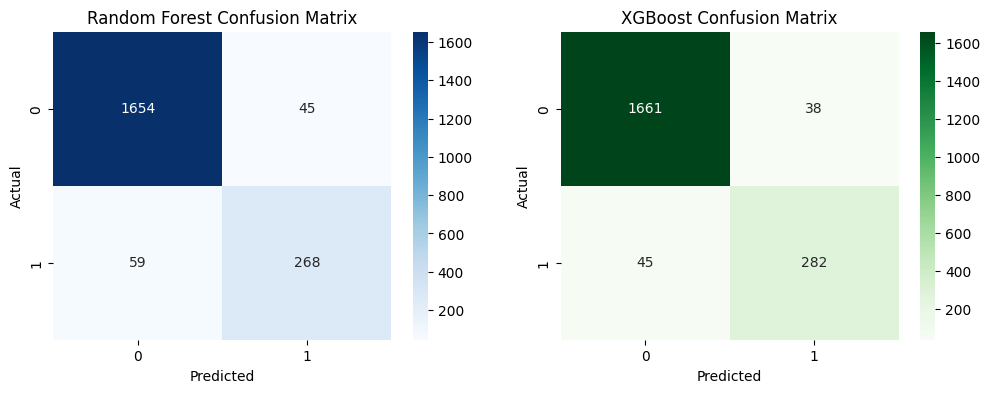

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

#confusion matrix RandomForest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Random Forest Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

#confusion matrix XGBoost
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('XGBoost Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.show()

note:
- Random Forest successfully detected 268 churn (True Positive), and let 59 churn (False Negative).
- XGBoost successfully detected 282 churn (True Positive), and let only 45 churn (False Negative).

so the conclusion,

XGBoost performs better than RandomForest because it has more true positives (TP) and fewer false negatives (FN). This means XGBoost detects more churn customers and misses fewer of them

In [ ]:
def print_metrics(name, y_true, y_pred, y_prob):
  print(f'\n--- {name} performance ---')
  print(classification_report(y_true, y_pred))
  print(f'ROC-AUC score: {roc_auc_score(y_true, y_prob)}')

#RandomForest
print_metrics('Random Forest', y_test, y_pred_rf, rf_model.predict_proba(x_test_encoded)[:, 1])

#XGBoost
print_metrics('XGBoost', y_test, y_pred_xgb, xgb_model.predict_proba(x_test_encoded)[:, 1])


--- Random Forest performance ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1699
           1       0.86      0.82      0.84       327

    accuracy                           0.95      2026
   macro avg       0.91      0.90      0.90      2026
weighted avg       0.95      0.95      0.95      2026

ROC-AUC score: 0.9810645945717305

--- XGBoost performance ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1699
           1       0.88      0.86      0.87       327

    accuracy                           0.96      2026
   macro avg       0.93      0.92      0.92      2026
weighted avg       0.96      0.96      0.96      2026

ROC-AUC score: 0.9884587623948609


note:
- Recall (0.86) & Revenue:
by detecting 86% of customers who may churn, the bank has a better chance to protect a large amount of annual revenue by taking proactive retention actions before the customers leave.
- Precision (0.88) & CAC:
because the precision is high (88%), the bank will not waste marketing or incentive costs on customers who actually will not churn. this helps keep operational costs, such as Customer Acquisition Cost (CAC), more efficient because retention efforts are targeted to the right customers.

conclusion:

based on the analysis, XGBoost is the best model. It performs better than Random Forest on the main metrics, especially Recall (0.86), Precision (0.88), and ROC-AUC (0.988). from a business perspective, XGBoost protects revenue and reduces CAC more effectively because it makes fewer prediction errors. therefore, it is the most suitable model for the bank’s churn prevention strategy.

# Model Interpretability Analysis

In [ ]:
#SHAP
import shap

In [ ]:
#initiate explainer
explainer = shap.TreeExplainer(xgb_model)

In [ ]:
#count SHAP for data test
shap_values = explainer.shap_values(x_test_encoded)

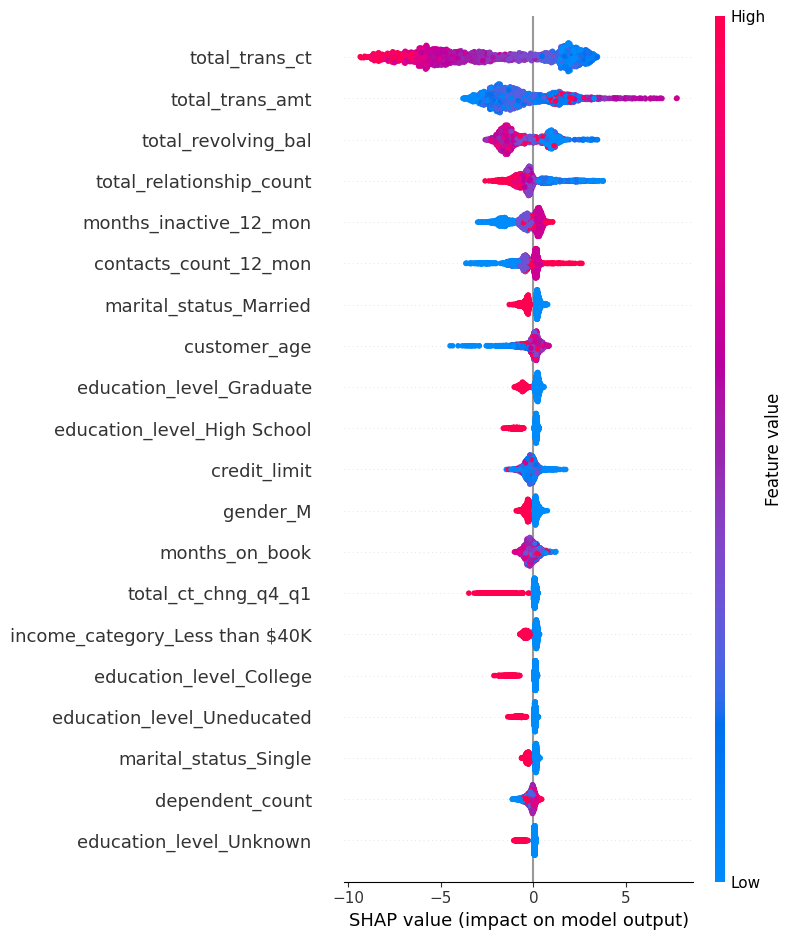

In [ ]:
#visualization
shap.summary_plot(shap_values, x_test_encoded)

In [ ]:
shap.initjs()

#explain prediction
shap.force_plot(explainer.expected_value, shap_values[0,:], x_test_encoded.iloc[0,:])

Numerical Features

**Total transaction count & amount**

- EDA: the analysis shows that customers with around 40 transactions and low transaction amounts have a higher chance of churning.
- SHAP: the feature total_trans_ct appears as the most important feature. high values (red dots) reduce churn risk, while low values (blue dots) increase the chance of churn. This shows that transaction activity is the strongest sign of customer loyalty in the model.

**Total Revolving Balance**

- EDA: customers with a balance close to 0 have the highest churn rate because they have less financial connection with the bank.
- SHAP: The feature total_revolving_bal is among the top 3 most important features. the model increases the churn risk for customers with low revolving balances.

Categorical features

**Gender & Marital Status**

- EDA: female customers have a slightly higher churn rate, while marital status is not very significant.
- SHAP: features such as gender_M and marital_status (Married or Single) appear near the bottom of the SHAP chart. this means that although EDA shows some differences, the model considers demographic features less important than transaction behavior for predicting churn.

**Education Level**
- EDA: customers with a Doctorate degree have the highest churn rate.
- SHAP: different education levels (such as education_level_Graduate or Uneducated) appear near the bottom of the chart. this shows that education background is only a supporting factor, not a main reason why customers stop using the credit card.

# Business Impact Simulation

**Identifikasi customer berisiko tinggi berdasarkan hasil prediksi model**

based on the model, 320 customers are predicted to be at risk of churn (282 True Positives + 38 False Positives). their main characteristics are a decrease in the number of transactions (total_trans_ct) and a revolving balance (total_revolving_bal) close to zero.

**Asumsi retensi biaya per customer**

- Average revenue per user: 3.095 (in currency)
- Retention cost (assumptions): 50 (in currency), promotion to prevent churn
- Success rate retention (assumptions): 50%

**Potensi revenue yang diselamatkan jika model digunakan**

- Customer saved: 282 (only from TP) x 50% = 141 (*****the 38 customers (False Positives) would stay with the bank anyway, so no revenue is actually saved from them)
- Gross revenue saved: 141 x 3095 (in currency) = 436.395 (in currency)
- Total retention cost: 320 x 50 (in currency) = 16.000 (in currency)
- Net revenue: 436.395 (in currency) - 16.000 (in currency) = 420.395 (in currency)

**Bandingkan skenario tanpa model dengan model**

without model:

we will lose 327 customers without retention, it means we lose 327 x 3.095 (in currency) = 1.012.065 (in currency)


with XGBoost model:
we can identify churn and do retention to 320 customers, so we can perform retention. even though the 38 customers are False Positives (they were predicted to churn but actually would stay), this causes some wasted retention cost. however, the bank still gains a net profit of 420,395 (in currency).


# Executive Summary

Jelaskan besar permasalahan churn, faktor utama penyebab churn, model terbaik yang dipilih, potensi dampak bisnis, serta rekomendasi prioritas.

**Besarnya permasalahan churn**

based on the model results, the bank risks losing 327 customers who may churn. Without an early detection system (modeling), the bank could face a potential loss of 1,012,065 (in currency).

**Faktor utama penyebab churn**

low activity:
a decrease in annual transaction count (total_trans_ct) and transaction amount (total_trans_amt) is the strongest sign that a customer may leave

financial engagement:
customers with a revolving balance (total_revolving_bal) close to zero have a very high chance of churn because they no longer actively use the credit card


**Model terbaik yang dipilih**

based on the analysis, XGBoost is the best model. It performs better than Random Forest on the main metrics, especially Recall (0.86), Precision (0.88), and ROC-AUC (0.988). from a business perspective, XGBoost protects revenue and reduces CAC more effectively because it makes fewer prediction errors. therefore, it is the most suitable model for the bank’s churn prevention strategy

**Potensi dampak bisnis**

by implementing this model and assuming a 50% retention success rate, the bank is expected to save a net revenue of 404.395 after deducting retention cost

**Rekomendasi prioritas**

- implement the XGBoost model in the bank’s system to predict customer churn and take preventive actions

- allocate a budget for programs such as discounts, promotions, cashback, and point redemption to help prevent customers from churning